# Project

# TO DOs
- SequencePersistence model
- XGBoosts: node specific
- LSTM: node specific
- implement horizons
- separate plotting module
- forecasting: double axes (inc. and cases)
- XGBoost: shallowdataloader
- comb through entire codebase
- save graph configs (see below)
- print aligned training (and initiation) statements

Basically this project aims to develop techniques for modelling epidemiological infections in Germany on a regional level, in both space and time. Ultimately, the goal is to predict the occurence of outbreaks in measles, both in time and space. Because measles casecounts are relatively sparse, I am developing tools and a workflow specific to influenza first. To that end, I have extracted influenza casenumbers per Kreis in Germany, between 2005-01-01 and 2024 (I think), totalling 1_613_862 cases over 400 Kreisen.

This project is aimed at developing the following, in regards to epidemiological modelling in Germany
- workflow (data normalization, visualization, loss)
- models
- graph structures
- task-specification (horizon (length and leadtime))

## Project outline

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
⚠️ you are connected to cpu, not to gpu

==Training boolean neighbors - logged + zscore==
Epoch 1 train loss: 0.0048, val loss: 0.0076 ✓ (new best)


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 609.22it/s]

Test loss: 0.0093


(<Figure size 1600x2000 with 4 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 26'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 391'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 69'}, ylabel='incidence'>],
       dtype=object))

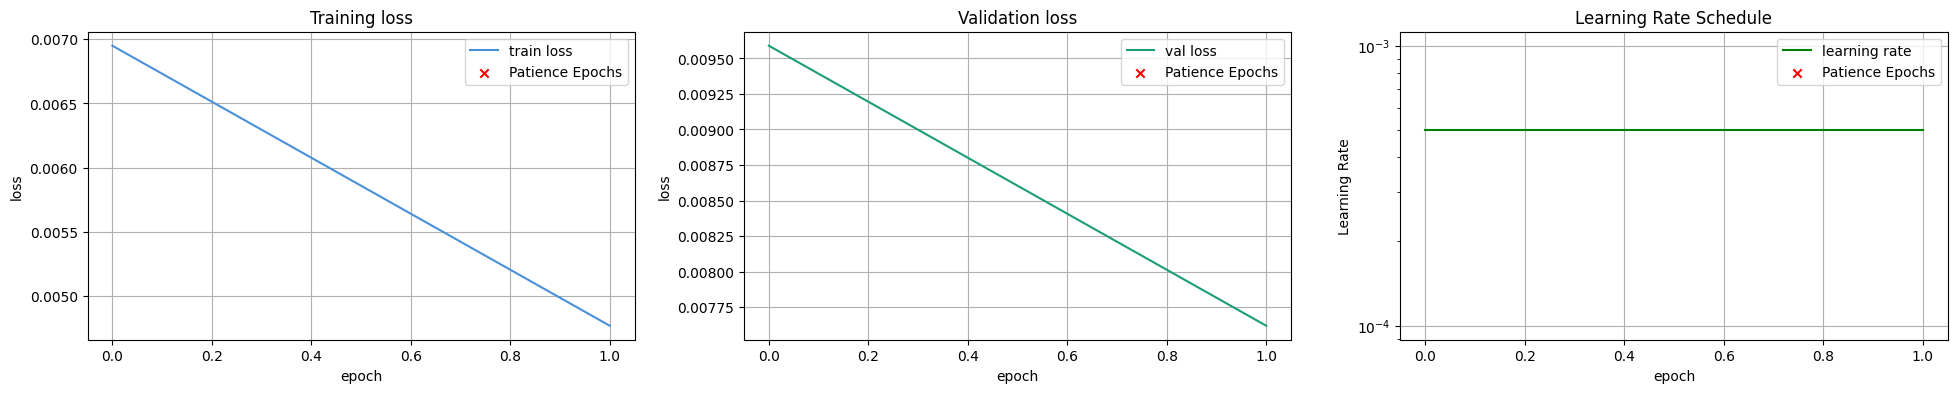

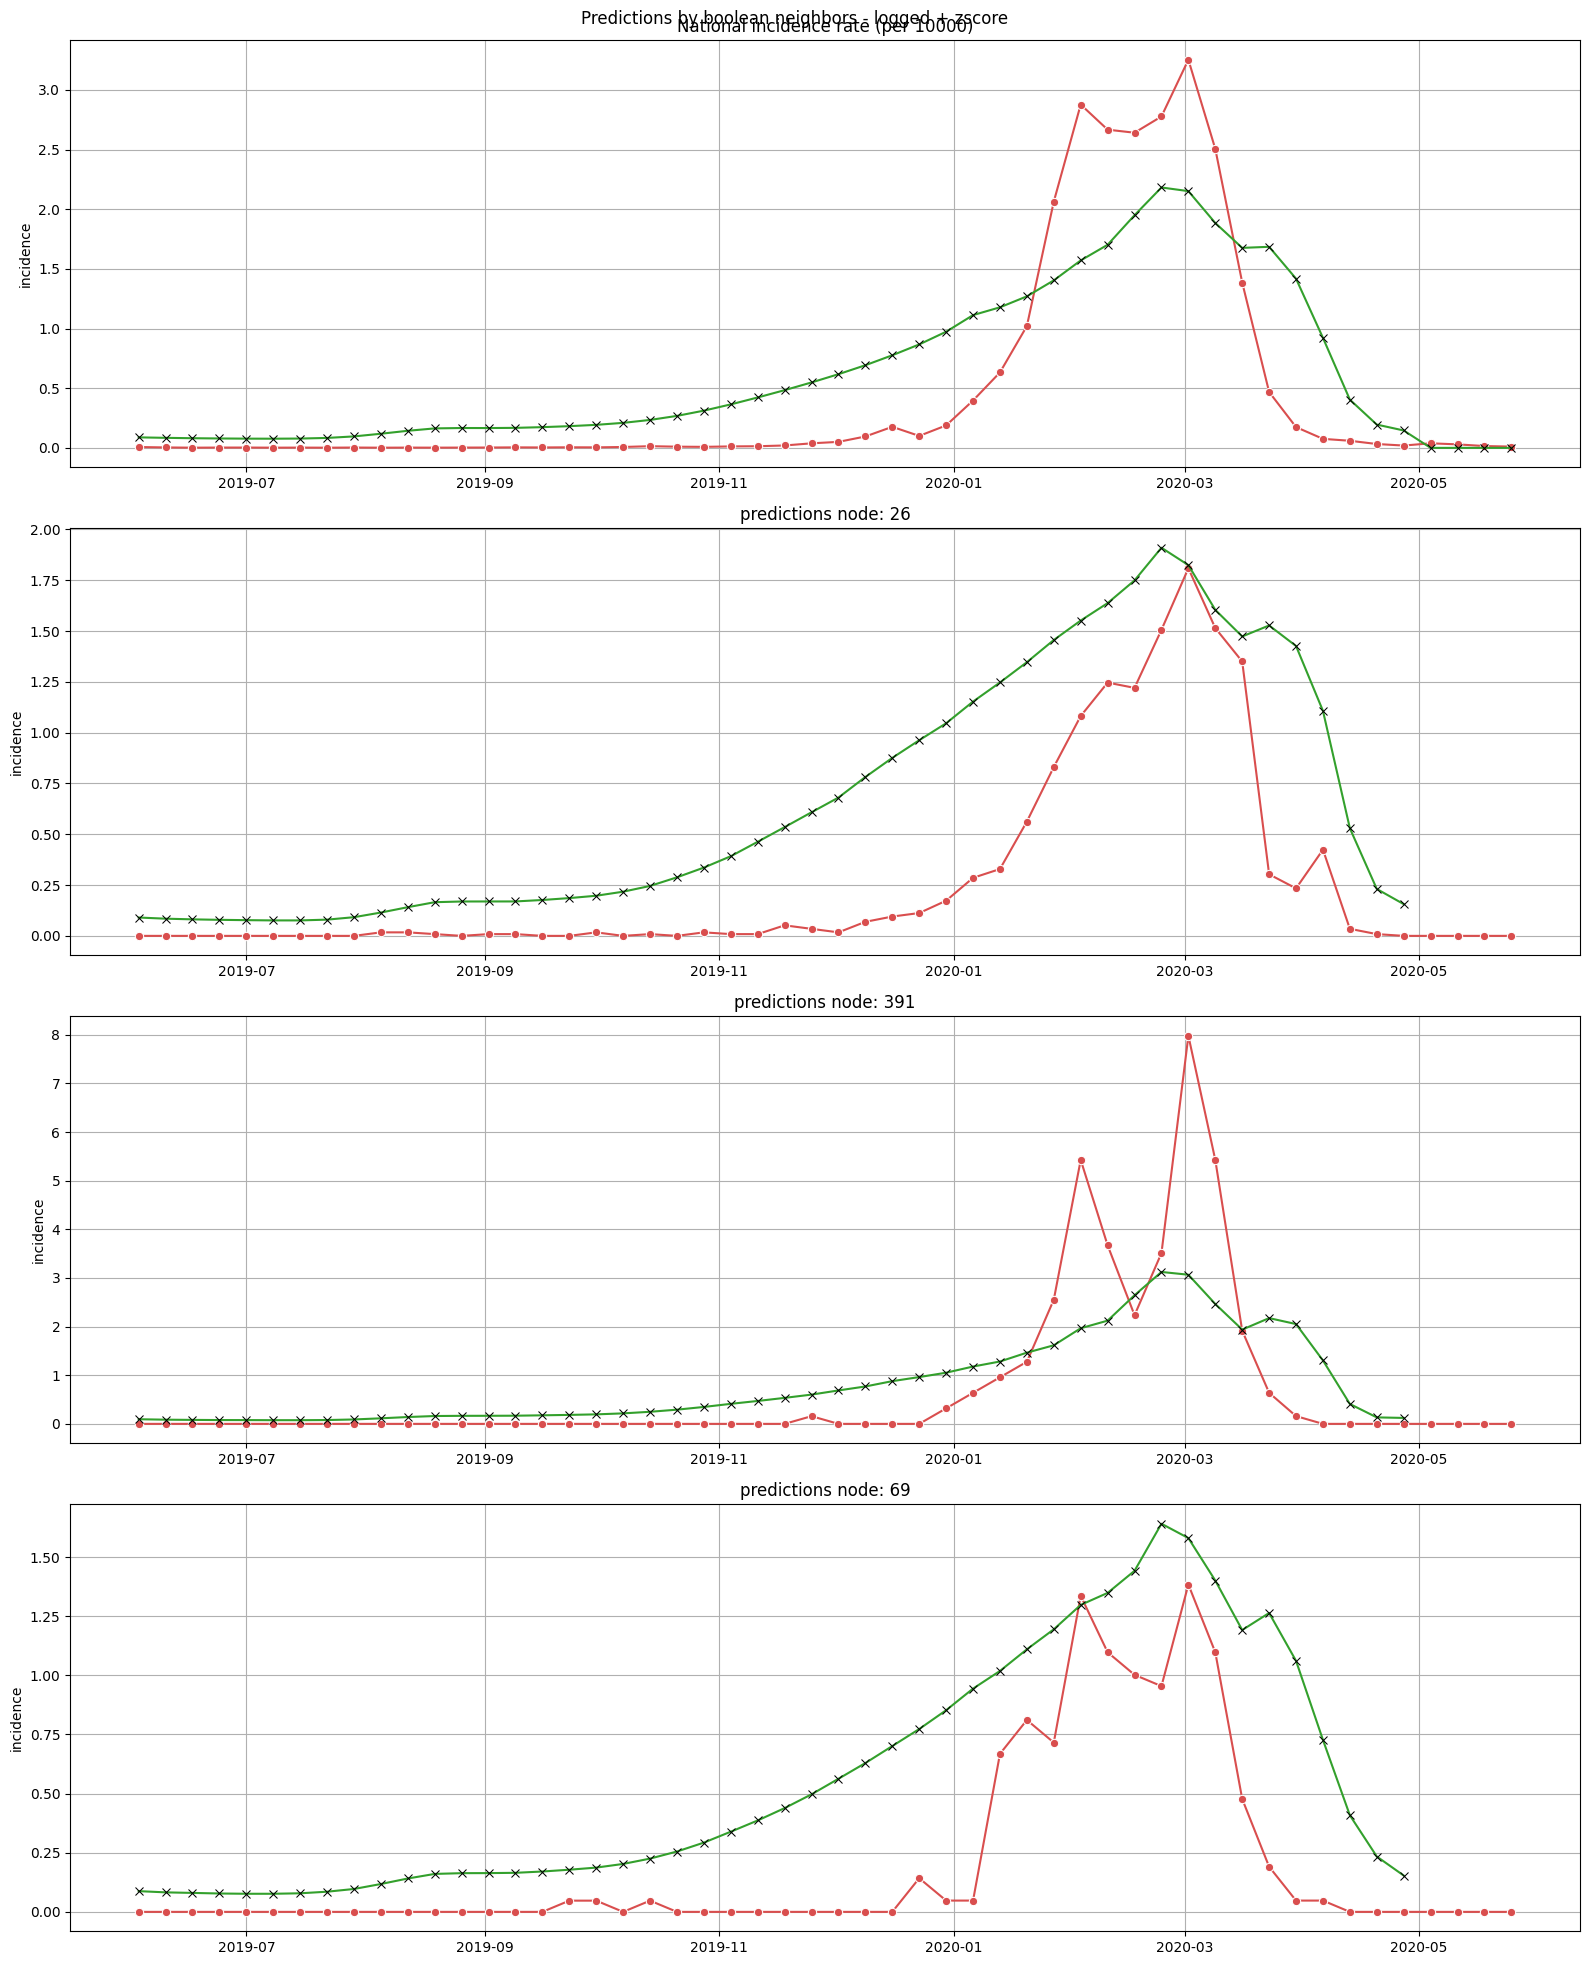

In [ ]:
from src.utils import get_data_env
from src.models import SpatialGNNModel
from src.dataloading import DeepDataLoader

disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 4

graphtype       = 'boolean_neighbors_self'
modelname       = 'boolean neighbors - spatial gcn'

# training hparams
n_epochs        = 2
lr              = 0.0005
min_delta       = 0.0001
loss            = 'exp_decay'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epidata_loader_bn_logged = DeepDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_bn_logged.add_time_features()
epidata_loader_bn_logged.log_transform_target()
epidata_loader_bn_logged.set_splits(split_trainval, split_valtest)
epidata_loader_bn_logged.normalize('minmax')
epidata_loader_bn_logged.add_lagged_features(lags = lags)
epidata_loader_bn_logged.finalize()
epidata_loader_bn_logged.retrieve_graph(graphtype)
epidata_loader_bn_logged.construct_dataloaders()

spatial_bn = SpatialGNNModel(epidata_loader_bn_logged, name = 'boolean neighbors - logged + zscore')
spatial_bn.set_model_hparams()
spatial_bn.set_global_hparams(**global_hparams)
spatial_bn.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
spatial_bn.forecast('test')
spatial_bn.show_forecasts('test', [26,391, 69], target_h=0)


'minmax'

I have created a couple of baseline models, htat may be compared to for evaluation purposes. For more information, see Chapter 2. Baselines.

- Persistence model: predictions are exactly the most recent values. In other words, upon a leadtime of $t_l$, the prediction for node $n$ at time $t$ is the incidence rate for node $n$ at time $t - t_l$
- SequencePersistence model: predictions are the extrapolation of the sequence of most recent values (only relevant if $L_{seq}$>1)

## Task-specification

In [25]:
from src.graphconstruction import GraphConstructor
from src.dataloading import DeepDataLoader, EpiDataLoader
from src.utils import get_data_env

epidata_nuts2 = EpiDataLoader('influenza', get_data_env(), nuts_level='nuts2', min_date='2001-05-15',max_date='2025-06-01', include_population=True)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags =1)
epidata_nuts2.finalize()



Dataloader temporal windowing: extending data collection from 2001-05-15 to 2001-05-01 (+2 weeks)


EpiDataLoader(disease=influenza, nuts_level=nuts2, min_date=2001-05-01, max_date=2025-06-01, horizon_size=1, horizon_leadtime=1, sequence_length=1)

## Workflow

## Models

I have mostly worked with:

- GATv2 
- SpatialGNN
- TGCN
- A3TGCN

## Graphs

In [ ]:


modelname       = 'gatv2model'
disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 1


# training hparams
n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epiloader = EpiDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epiloader.add_time_features()
epiloader.log_transform_target()
epiloader.set_splits(split_trainval, split_valtest)
epiloader.normalize()
epiloader.add_lagged_features(lags = lags)
epiloader.finalize()

epidata_loader_basis = DeepDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

graphconstruction = GraphConstructor(epidata = epidata_loader_basis)
graphconstruction.generate_graph(
    method='identity', 
    self_connection='0'
    )

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    self_connection='max',
)

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    self_connection='0',
)
# long distance, sparse
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 3,
    alpha = 1,
    decay = 1,
    scaling_method='rowwise'
)

# long distance, dense
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 7,
    alpha = 1,
    decay = 1,
    scaling_method='rowwise',
    name_addition='2'
)

# more locally oriented, sparse
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 3,
    alpha = 2,
    decay = 1,
    scaling_method='rowwise',
    name_addition='3'
)


# more locally oriented, denser
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 7,
    alpha = 2,
    decay = 1,
    scaling_method='rowwise',
    name_addition='4'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='0',
    commuter_type = 'static',
    commuting_threshold = 1000,
    top_k = 4,
    scaling_method='rowwise',
    name_addition='1'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='mean',
    commuter_type = 'static',
    commuting_threshold = 1000,
    top_k = 4,
    scaling_method='rowwise',
    name_addition='2'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='0',
    commuter_type = 'static',
    commuting_threshold = 1000,
    scaling_method='rowwise',
    name_addition='3'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='mean',
    commuter_type = 'static',
    commuting_threshold = 1000,
    scaling_method='rowwise',
    name_addition='4'
)

graphconstruction.rename_graph('identity_self0',                'identity_graph')
graphconstruction.rename_graph('boolean_neighbors_selfmax',     'boolean_neighbors_self')
graphconstruction.rename_graph('boolean_neighbors_self0',       'boolean_neighbors_nonself')
graphconstruction.rename_graph('gravity_model_self0_rowwise',   'gravity1')
graphconstruction.rename_graph('gravity_model_2_self0_rowwise', 'gravity2')
graphconstruction.rename_graph('gravity_model_3_self0_rowwise', 'gravity3')
graphconstruction.rename_graph('gravity_model_4_self0_rowwise', 'gravity4')
graphconstruction.rename_graph('commuter_1_self0_rowwise',      'commuter1')
graphconstruction.rename_graph('commuter_2_selfmean_rowwise',   'commuter2')
graphconstruction.rename_graph('commuter_3_self0_rowwise',      'commuter3')
graphconstruction.rename_graph('commuter_4_selfmean_rowwise',   'commuter4')
# graphconstruction.save_graph('all')

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
✓ graph generated: identity_self0
✓ graph generated: boolean_neighbors_selfmax
✓ graph generated: boolean_neighbors_self0
✓ graph generated: gravity_model_self0_rowwise
✓ graph generated: gravity_model_2_self0_rowwise
✓ graph generated: gravity_model_3_self0_rowwise
✓ graph generated: gravity_model_4_self0_rowwise
✓ graph generated: commuter_1_self0_rowwise
✓ graph generated: commuter_2_selfmean_rowwise
✓ graph generated: commuter_3_self0_rowwise
✓ graph generated: commuter_4_selfmean_rowwise
identity_self0 has been replaced by identity_graph
boolean_neighbors_selfmax has been replaced by boolean_neighbors_self
boolean_neighbors_self0 has been replaced by boolean_neighbors_nonself
gravity_model_self0_rowwise has been replaced by gravity1
gravit

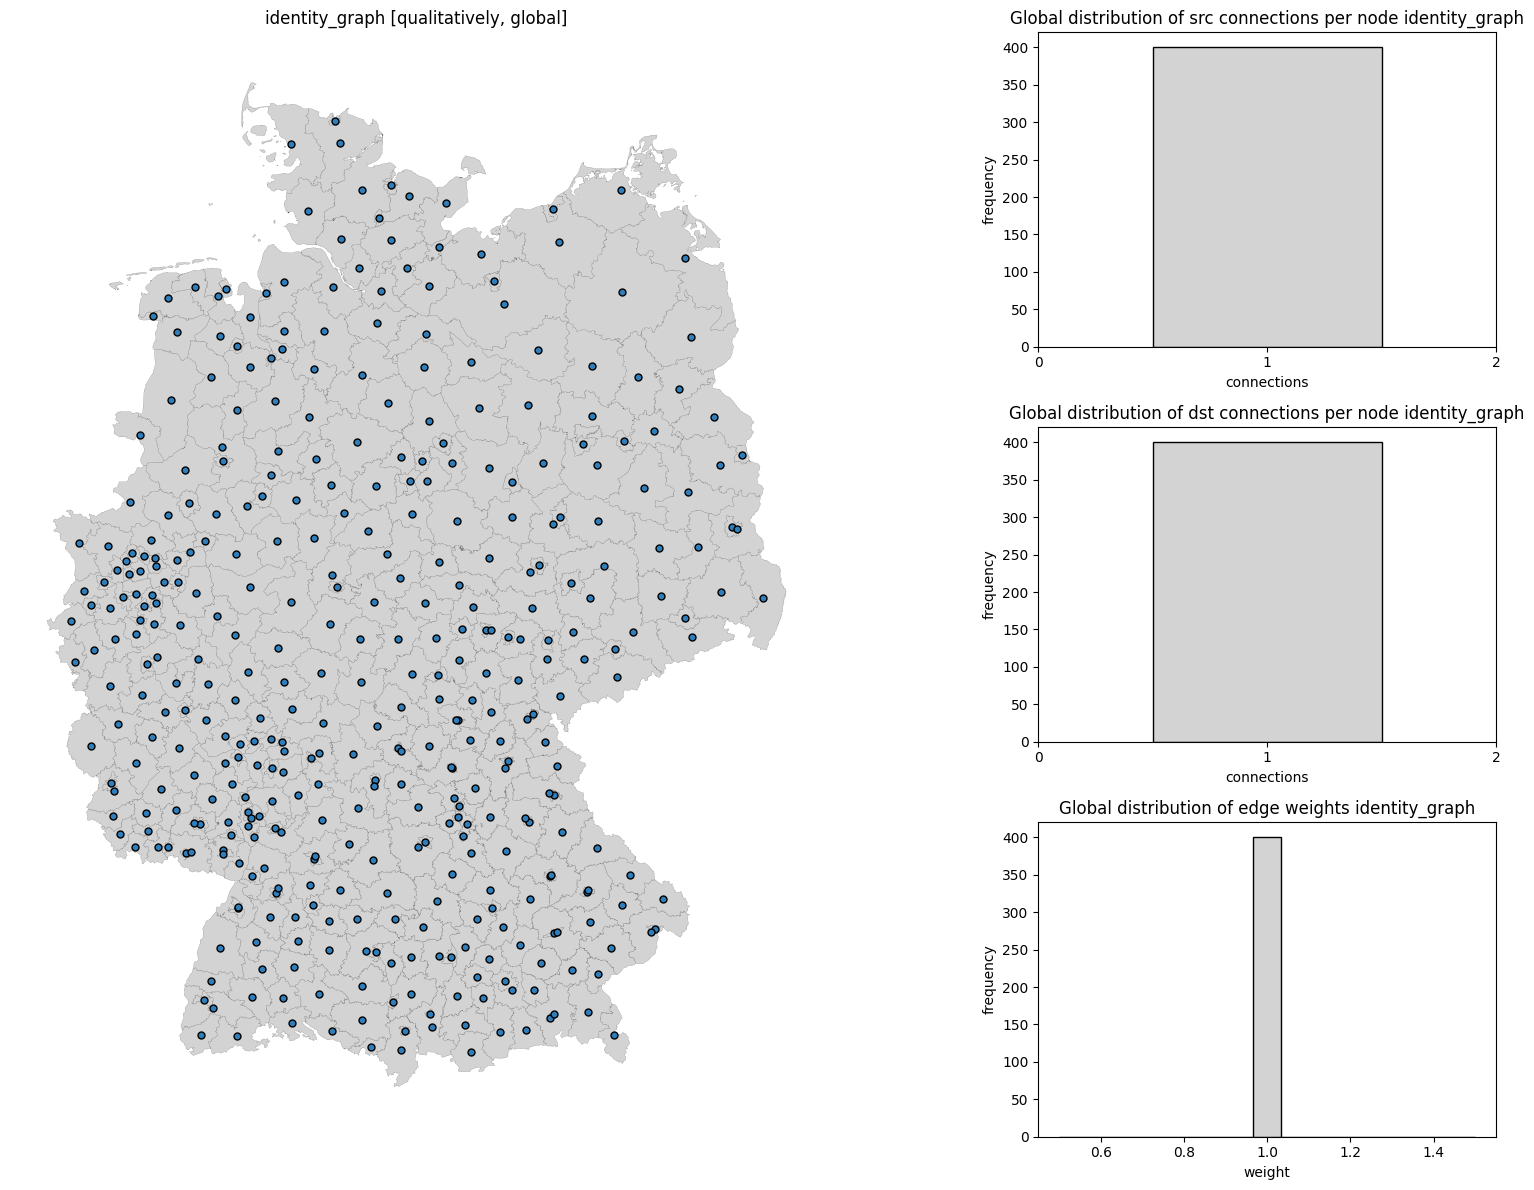

In [2]:
graphconstruction.preview_graph('identity_graph','all')

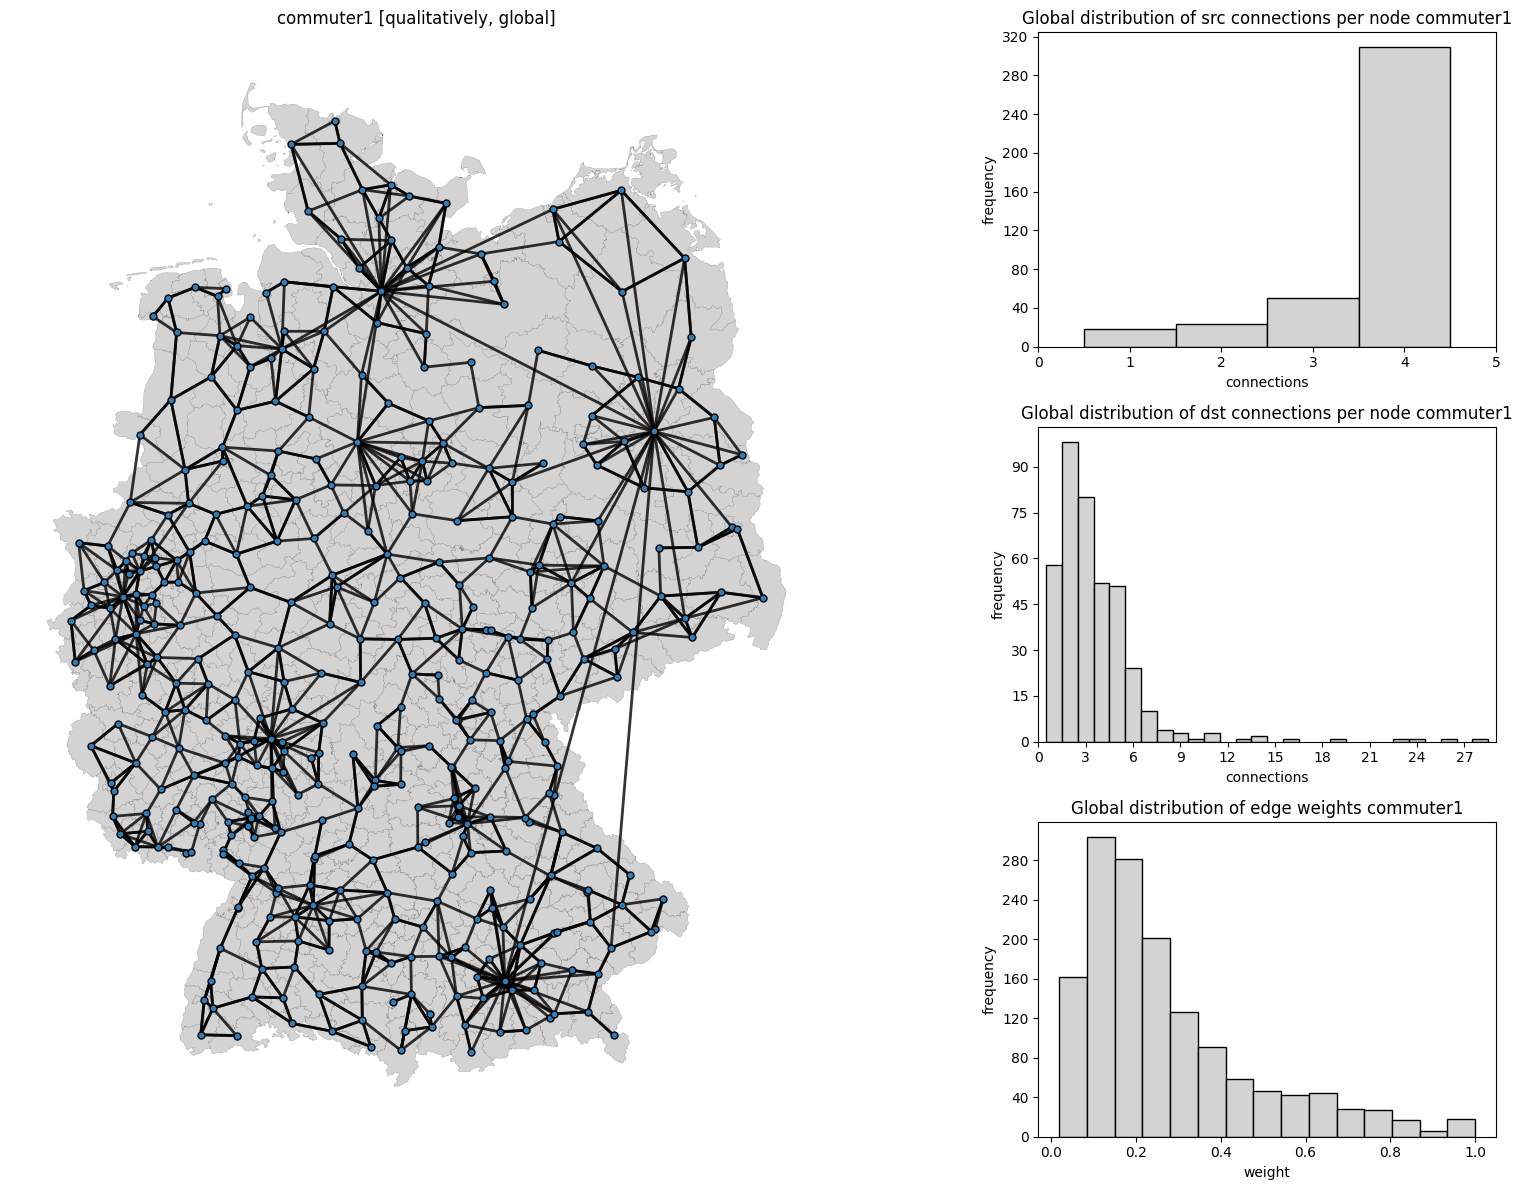

In [3]:
graphconstruction.preview_graph('commuter1','all')

Dataloader temporal windowing: extending data collection from 2001-05-15 to 2001-05-01 (+2 weeks)


EpiDataLoader(disease=influenza, nuts_level=nuts2, min_date=2001-05-01, max_date=2025-06-01, horizon_size=1, horizon_leadtime=1, sequence_length=1)